# When the Detector Hands You a Hole in the Data
### 2.6 — Missing Values and Detector Dropouts

Real spectra arrive with gaps. A detector drops a reading, a pixel saturates, a
channel goes dead. In Python those show up as `NaN` (not-a-number), and the
temptation is to make them disappear so the code runs. That's a mistake: **a NaN
is a record that the instrument did not measure a trustworthy value there**, and
what you do about it changes your result.

> **One idea to hold onto:** treat a missing value as a measurement event, not a
> nuisance. *Drop*, *interpolate*, or *flag* — each is a scientific choice with a
> different consequence, so decide on purpose.

**By the end of this notebook you will be able to:**

1. Find and count missing values.
2. Tell a detector dropout from a saturation from a dead channel.
3. Choose drop vs interpolate vs flag, knowing what each does to the data.

## 1. Where NaNs come from

A short absorbance spectrum with two real problems baked in: two **dropouts** the
detector failed to report (`NaN`), and one **saturated** point clipped at the
detector ceiling. We'll treat them differently, because they are different events.

In [1]:
import numpy as np
import pandas as pd

wl = np.arange(500, 512, dtype=float)   # 12-point wavelength axis (nm)
absorbance = np.array([0.10, 0.14, 0.21, np.nan, 0.36, 0.45,
                       3.50, 0.51, 0.40, np.nan, 0.18, 0.12])
#                                  ^dropout      ^saturated (clipped) ^dropout

DETECTOR_CEILING = 3.5   # the instrument cannot report above this

print("spectrum:", absorbance)

spectrum: [0.1  0.14 0.21  nan 0.36 0.45 3.5  0.51 0.4   nan 0.18 0.12]


## 2. Detect and count

You can't decide what to do until you know where the gaps are. `np.isnan` locates
missing values; on a table, `df.isna().sum()` counts them per column.

In [2]:
missing_mask = np.isnan(absorbance)
print("missing points:", int(missing_mask.sum()), "of", absorbance.size)
print("at wavelengths:", wl[missing_mask], "nm")

missing points: 2 of 12
at wavelengths: [503. 509.] nm


## 3. Saturation is not "missing" — it's "wrong-high"

A clipped reading isn't absent; it's present but untrustworthy. A point sitting
exactly at the detector ceiling can't be believed, so the honest move is to convert
it to `NaN` — turning a *wrong* number into an *acknowledged* gap.

In [3]:
cleaned = absorbance.copy()
saturated = cleaned >= DETECTOR_CEILING
print("saturated points:", int(saturated.sum()), "at", wl[saturated], "nm")

cleaned[saturated] = np.nan          # don't trust a clipped value
print("after flagging saturation:", cleaned)
print("total gaps now:", int(np.isnan(cleaned).sum()))

saturated points: 1 at [506.] nm
after flagging saturation: [0.1  0.14 0.21  nan 0.36 0.45  nan 0.51 0.4   nan 0.18 0.12]
total gaps now: 3


## 4. The decision: drop, interpolate, or flag

Three options, three consequences:

- **Drop** — remove the missing points (or the whole sample). Honest and simple, but
  it shortens the spectrum and breaks a fixed wavelength grid, and dropping a whole
  sample loses it from the batch. Fine when gaps are few and random.
- **Interpolate** — estimate the missing value from its neighbours. Reasonable for a
  single dropout in a smooth region; **dangerous on or near a peak**, where it
  invents signal and biases any area or height you compute. Interpolated points are
  not measurements — they are guesses.
- **Flag** — keep the `NaN` and carry a marker so every later step knows the value is
  missing. Safest for provenance: nothing is invented and nothing is silently lost.

Let's do each.

In [4]:
s = pd.Series(cleaned, index=wl)

# DROP: keep only measured points (note the spectrum gets shorter).
dropped = s.dropna()
print("drop  -> kept", dropped.size, "of", s.size, "points")

# INTERPOLATE: linearly fill gaps from neighbours (a guess, not a measurement).
interpolated = s.interpolate(method="linear")
print("interp-> filled values at gaps:",
      np.round(interpolated[np.isnan(cleaned)].to_numpy(), 3))

# FLAG: keep NaNs, add a boolean column recording where data is missing.
flagged = pd.DataFrame({"absorbance_AU": cleaned, "is_missing": np.isnan(cleaned)}, index=wl)
print("\nflagged table (missing kept and marked):")
print(flagged)

drop  -> kept 9 of 12 points
interp-> filled values at gaps: [0.285 0.48  0.29 ]

flagged table (missing kept and marked):
       absorbance_AU  is_missing
500.0           0.10       False
501.0           0.14       False
502.0           0.21       False
503.0            NaN        True
504.0           0.36       False
505.0           0.45       False
506.0            NaN        True
507.0           0.51       False
508.0           0.40       False
509.0            NaN        True
510.0           0.18       False
511.0           0.12       False


## 5. See why interpolation needs judgement

Plotting the measured points against the interpolated fill shows what interpolation
actually does: it draws a straight line across the gap. In a smooth stretch that's
fine; sitting on a peak it would quietly underestimate the true value.

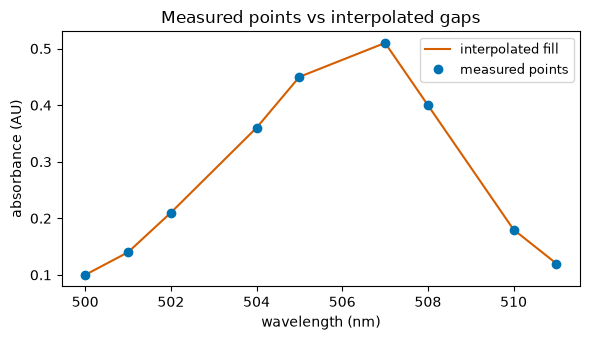

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(wl, interpolated.to_numpy(), "-", color="#D55E00", label="interpolated fill")
ax.plot(wl, cleaned, "o", color="#0072B2", label="measured points")
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("absorbance (AU)")
ax.set_title("Measured points vs interpolated gaps")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Key Takeaways

- A `NaN` is a **measurement event** — the instrument didn't return a trustworthy value.
- **Saturation** is wrong-high, not missing; convert clipped points to `NaN` honestly.
- **Drop / interpolate / flag** each have consequences: dropping shortens data,
  interpolating invents it, flagging preserves the truth.
- Interpolating on or near a **peak** biases any height or area you later compute.

## Practical Checklist

- [ ] Count and locate missing values before doing anything else.
- [ ] Treat saturated/clipped points as untrustworthy (set to `NaN`).
- [ ] Choose drop / interpolate / flag deliberately, and record which you used.
- [ ] Never interpolate across a peak without saying so.

## Common Mistakes

- Silently filling NaNs with 0 — a fabricated low reading that biases averages.
- Interpolating across a real feature and treating the guess as data.
- Dropping rows without noticing a whole sample (or wavelength grid) was lost.

## Next Lesson

**2.7 — Joining Measurements and Metadata.** With clean measurements in hand, next we
reunite them with the sample metadata that arrived in a separate file.